In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import time
from utils.colors import C2
from utils.problem_setup import TestProblemsSetup
from utils.utils import progress_bar, disk_cache

from algorithms.cg_solvers import DynamicalLowRankCG

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
setup = TestProblemsSetup(64)
problems = setup.get_test_problems(compute_weights=True)
problem_params = setup.problem_params

pid = 'I'
p = problems[pid]

In [29]:
@disk_cache('../../results/DLRA_CG_computational_breakdown')
def experiment(
    N_range: np.ndarray,
    rtol: float,
    repeat: int = 1,
    pid: str = 'I',
    k: int = 25,
) -> pd.DataFrame:

    record = []

    step, n_steps = 1, len(N_range) * repeat
    for N in N_range:
        # Setup and train an rSVD solver
        n = round(np.sqrt(N))
        setup = TestProblemsSetup(n=n)
        p = setup.problem_setup(
            params=setup.problem_params[pid],
            compute_weights=True,
            k=k
        )

        for _ in range(repeat):
            results = {'N': N} 
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1

            # Solve using DLRA-CG
            solver_dlr = DynamicalLowRankCG(p['rsvd'])
            t0 = time()
            solver_dlr.solve(
                y=p['y'],
                w=p['w'],
                lambda_=(1e-4)**2,
                rtol=rtol,
                max_iter=1000,
                max_rank=1,
                verbose=False
            )

            results['setup-time'] = solver_dlr.setup_time
            results['CG-time'] = solver_dlr.CG_time
            results['WLS-time'] = solver_dlr.WLS_time
            results['truncate-time'] = solver_dlr.truncate_time
            record.append(results)
        
    return pd.DataFrame(record)

  

In [34]:
N_range = np.linspace(1_000, 100_000, 21, dtype=int)

params = [
    {'N_range': N_range, 'rtol': 1e-8, 'repeat': 10},
    #{'N_range': N_range, 'rtol': 1e-12, 'repeat': 5},
]

results = {p['rtol']: experiment(**p) for p in params}

[##############################] 210/210 [N=100,000]


In [35]:
df = results[1e-8]
df = df.groupby(['N']).agg('median').reset_index()

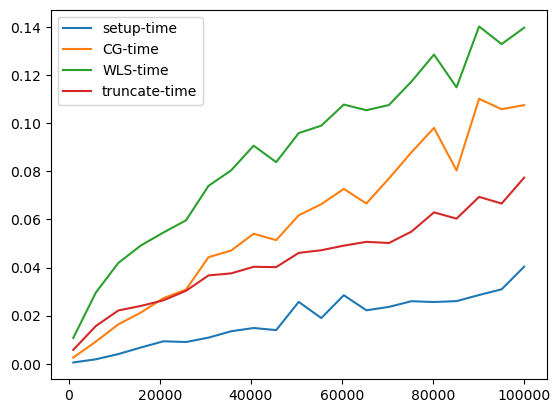

In [36]:
fig, ax = plt.subplots(1, 1)
cols = [c for c in df.columns if c != 'N']

for c in cols:
    ax.plot(df.N, df[c], label=c)

ax.legend()